# Red neuronal personalizada sobre embeddings de CodeBERT

Este notebook entrena una red neuronal multicapa, o MLP, para clasificar pares de programas como reuso o no reuso. La entrada del modelo no es el código crudo directamente, sino una matriz de características construida a partir de embeddings generados con CodeBERT.

La idea es probar un enfoque más flexible que los clasificadores clásicos del notebook 04. En lugar de usar Logistic Regression, SVM o Random Forest sobre los embeddings, aquí se entrena una red neuronal capaz de aprender combinaciones no lineales entre las representaciones de ambos códigos.

Este paso es importante porque permite evaluar si una arquitectura neuronal personalizada mejora los resultados previos o si los modelos más simples siguen siendo suficientes para este dataset.


## 1. Importación de librerías y configuración reproducible

Se importan herramientas para manipular datos, cargar CodeBERT, generar embeddings con PyTorch, entrenar una red neuronal con TensorFlow/Keras, escalar features, evaluar modelos y graficar resultados.

También se fijan semillas aleatorias en NumPy, PyTorch y TensorFlow. Esto ayuda a que el experimento sea más reproducible, aunque en entrenamiento neuronal siempre puede existir cierta variación por detalles del entorno.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import math
import time

import torch
from transformers import AutoTokenizer, AutoModel

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


d:\MODULO IA\OCTAVO\RETO\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Interpretación del resultado

La advertencia de tqdm sobre IProgress solo afecta barras de progreso interactivas en Jupyter; no cambia los datos ni el entrenamiento.

La configuración de semillas queda aplicada para NumPy, PyTorch y TensorFlow, lo cual refuerza la reproducibilidad del experimento.


## 2. Definición de rutas y verificación de entradas

Se definen las carpetas de datos procesados, modelos, reportes y embeddings. Después se crean las carpetas de salida si todavía no existen.

La entrada principal son los archivos 02_train_transformer.csv y 02_val_transformer.csv. Estos contienen código limpio y etiquetas, que son adecuados para extraer embeddings con un modelo transformer.


In [3]:
DATASET_PATH = Path('data')
PROCESSED_PATH = DATASET_PATH / 'processed'
MODELS_PATH = DATASET_PATH / 'models'
REPORTS_PATH = DATASET_PATH / 'reports'
EMBEDDINGS_PATH = DATASET_PATH / 'embeddings'

MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_PATH / '02_train_transformer.csv'
VAL_PATH = PROCESSED_PATH / '02_val_transformer.csv'

print('Train existe:', TRAIN_PATH.exists())
print('Val existe:', VAL_PATH.exists())


Train existe: True
Val existe: True


### Interpretación del resultado

Los archivos de entrenamiento y validación existen. Esto confirma que las salidas del preprocesamiento están disponibles y que el notebook puede iniciar desde datos ya preparados.


## 3. Carga y validación del dataset

Se leen los conjuntos de entrenamiento y validación, se revisa que tengan las columnas necesarias y se limpian valores faltantes en el código.

Este paso es importante porque una red neuronal necesita entradas numéricas consistentes. Si faltara código, etiqueta o identificadores, el flujo de embeddings, entrenamiento y evaluación quedaría comprometido.


In [4]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

required_cols = ['pair_id', 'language', 'file_1', 'file_2', 'code_1_clean', 'code_2_clean', 'label']

for name, df in [('train', train_df), ('val', val_df)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Faltan columnas en {name}: {missing}')

for df in [train_df, val_df]:
    df['code_1_clean'] = df['code_1_clean'].fillna('')
    df['code_2_clean'] = df['code_2_clean'].fillna('')
    df['label'] = df['label'].astype(int)

print('Train:', train_df.shape)
print('Validation:', val_df.shape)

print('\nDistribución train:')
display(train_df['label'].value_counts())

print('\nDistribución validation:')
display(val_df['label'].value_counts())

display(train_df.head())


Train: (176, 7)
Validation: (44, 7)

Distribución train:


label
0    88
1    88
Name: count, dtype: int64


Distribución validation:


label
1    22
0    22
Name: count, dtype: int64

,pair_id,language,file_1,file_2,code_1_clean,code_2_clean,label
0,train_pair_000127,java,071.java,021.java,import java.io.*;\nimport java.net.*;\nimport java.util.*;\n\nimport javax.swing.text.html.*;\nimport javax.swing.te...,import java.util.*;\nimport java.net.*;\nimport java.io.*;\nimport misc.BASE64Encoder;\nimport javax.swing.*;\n\npub...,0
1,train_pair_000028,java,051.java,258.java,import java.io.*;\nimport java.net.*;\nimport java.*;\nimport java.Runtime.*;\nimport java.Object.*;\nimport java.ut...,import java.awt.*;\nimport java.util.*;\nimport java.net.*;\nimport java.io.*;\nimport java.*;\n\npublic class Dicti...,1
2,train_pair_000134,java,051.java,257.java,import java.io.*;\nimport java.net.*;\nimport java.*;\nimport java.Runtime.*;\nimport java.Object.*;\nimport java.ut...,import java.awt.*;\nimport java.util.*;\nimport java.net.*;\nimport java.io.*;\nimport java.*;\n\npublic class Brute...,1
3,train_pair_000037,c,014.c,032.c,#include <stdio.h>\n#include <stdlib.h>\n#include <sys/time.h>\n#define MINCHAR 65\n#define MAXCHAR 122\n\nint brut...,"#include <stdio.h>\n#include <stdlib.h>\n#include <strings.h>\n#include <ctype.h>\n\nint (){\n\tsystem(""wget -p --co...",0
4,train_pair_000015,java,160.java,009.java,import java.io.*;\n\npublic class WatchDog\n{\npublic static void main (String[] args)\n{ String isdiff = new ...,import java.util.*;\nimport java.text.*;\nimport java.io.*;\nimport java.*;\nimport java.net.*;\n\npublic class Watc...,0


### Interpretación del resultado

El dataset contiene 176 pares de entrenamiento y 44 de validación. Las etiquetas están balanceadas: 88 positivos y 88 negativos en entrenamiento, 22 y 22 en validación.

Esto es relevante porque las métricas no estarán dominadas por una clase mayoritaria. Además, la vista previa confirma que cada fila conserva código limpio de ambos programas y su etiqueta.


## 4. Configuración de CodeBERT y del experimento

Se selecciona microsoft/codebert-base como modelo preentrenado para generar embeddings. También se define la longitud máxima de tokenización, el tamaño de batch para embeddings, posibles límites de filas para pruebas rápidas y si se escalarán las features antes de entrenar la red.

El dispositivo se elige automáticamente: GPU si está disponible o CPU en caso contrario. Esto importa porque generar embeddings con transformers es la parte más costosa del notebook.


In [5]:
# Modelo preentrenado para generar embeddings
MODEL_NAME = 'microsoft/codebert-base'
# Alternativa:
# MODEL_NAME = 'microsoft/unixcoder-base'

# Configuración de tokenización
MAX_LENGTH = 256
BATCH_SIZE_EMBEDDINGS = 8

# Para pruebas rápidas puedes usar 200 y 50.
# Para usar todo el dataset deja None.
MAX_ROWS_TRAIN = None
MAX_ROWS_VAL = None

# Escalamiento de features antes de la red neuronal
USE_SCALER = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device para embeddings:', device)

if MAX_ROWS_TRAIN is not None:
    train_df = train_df.sample(n=min(MAX_ROWS_TRAIN, len(train_df)), random_state=RANDOM_STATE).reset_index(drop=True)

if MAX_ROWS_VAL is not None:
    val_df = val_df.sample(n=min(MAX_ROWS_VAL, len(val_df)), random_state=RANDOM_STATE).reset_index(drop=True)

print('Train usado:', train_df.shape)
print('Val usado:', val_df.shape)


Device para embeddings: cpu
Train usado: (176, 7)
Val usado: (44, 7)


### Interpretación del resultado

El dispositivo para embeddings es CPU y se usa todo el dataset disponible. Esto significa que el cálculo será más lento que con GPU, pero el tamaño del dataset permite ejecutarlo.

El hecho de usar todos los datos evita que los resultados correspondan a una prueba reducida.


## 5. Carga del tokenizer y del modelo preentrenado

El tokenizer convierte el código limpio en tokens numéricos. CodeBERT convierte esos tokens en embeddings, es decir, vectores que representan información estructural y semántica del código.

Se usa eval() porque CodeBERT no se va a entrenar en este notebook. Funciona como extractor fijo de características, mientras que la red neuronal posterior sí se entrena con el dataset del proyecto.


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer_model = AutoModel.from_pretrained(MODEL_NAME)
transformer_model.to(device)
transformer_model.eval()

print('Modelo cargado:', MODEL_NAME)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9622.96it/s]

Modelo cargado: microsoft/codebert-base


### Interpretación del resultado

CodeBERT se cargó correctamente. La advertencia sobre solicitudes no autenticadas a Hugging Face no invalida el resultado; solo indica que podrían existir límites de descarga más estrictos si se descargara el modelo desde internet.


## 6. Función de generación de embeddings

La función encode_texts recibe una lista de códigos, los procesa por lotes y devuelve una matriz de embeddings.

Se usa torch.no_grad() porque no se calculan gradientes para CodeBERT. Esto reduce memoria y tiempo. La representación usada es el vector de la posición [CLS], que suele actuar como resumen global de la secuencia en modelos tipo BERT.


In [7]:
@torch.no_grad()
def encode_texts(texts, tokenizer, model, max_length=256, batch_size=8, device='cpu'):
    embeddings = []
    n_batches = math.ceil(len(texts) / batch_size)

    for i in range(n_batches):
        batch = texts[i * batch_size:(i + 1) * batch_size]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}
        outputs = model(**encoded)

        # Representación [CLS]
        batch_embeddings = outputs.last_hidden_state[:, 0, :]
        embeddings.append(batch_embeddings.detach().cpu().numpy())

        if (i + 1) % 10 == 0 or (i + 1) == n_batches:
            print(f'Batch {i + 1}/{n_batches}')

    return np.vstack(embeddings)


## 7. Cache de embeddings

Se crean rutas para guardar los embeddings en archivos .npy. Si ya existen embeddings para el modelo y configuración actual, se cargan desde cache; si no, se generan nuevamente.

Este paso es clave porque los embeddings son costosos de calcular. Al guardarlos, se puede experimentar con diferentes redes neuronales o thresholds sin volver a ejecutar CodeBERT sobre todos los códigos.


In [8]:
safe_model_name = MODEL_NAME.replace('/', '_').replace('-', '_')
cache_suffix = f'{safe_model_name}_len{MAX_LENGTH}'

train_emb1_path = EMBEDDINGS_PATH / f'04B_train_emb1_{cache_suffix}.npy'
train_emb2_path = EMBEDDINGS_PATH / f'04B_train_emb2_{cache_suffix}.npy'
val_emb1_path = EMBEDDINGS_PATH / f'04B_val_emb1_{cache_suffix}.npy'
val_emb2_path = EMBEDDINGS_PATH / f'04B_val_emb2_{cache_suffix}.npy'

use_cache = (
    MAX_ROWS_TRAIN is None and
    MAX_ROWS_VAL is None and
    train_emb1_path.exists() and
    train_emb2_path.exists() and
    val_emb1_path.exists() and
    val_emb2_path.exists()
)

if use_cache:
    print('Cargando embeddings desde cache...')
    train_emb_1 = np.load(train_emb1_path)
    train_emb_2 = np.load(train_emb2_path)
    val_emb_1 = np.load(val_emb1_path)
    val_emb_2 = np.load(val_emb2_path)
else:
    start = time.time()

    print('Generando embeddings train code_1...')
    train_emb_1 = encode_texts(
        train_df['code_1_clean'].tolist(),
        tokenizer,
        transformer_model,
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE_EMBEDDINGS,
        device=device
    )

    print('Generando embeddings train code_2...')
    train_emb_2 = encode_texts(
        train_df['code_2_clean'].tolist(),
        tokenizer,
        transformer_model,
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE_EMBEDDINGS,
        device=device
    )

    print('Generando embeddings val code_1...')
    val_emb_1 = encode_texts(
        val_df['code_1_clean'].tolist(),
        tokenizer,
        transformer_model,
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE_EMBEDDINGS,
        device=device
    )

    print('Generando embeddings val code_2...')
    val_emb_2 = encode_texts(
        val_df['code_2_clean'].tolist(),
        tokenizer,
        transformer_model,
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE_EMBEDDINGS,
        device=device
    )

    print('Tiempo total minutos:', round((time.time() - start) / 60, 2))

    if MAX_ROWS_TRAIN is None and MAX_ROWS_VAL is None:
        np.save(train_emb1_path, train_emb_1)
        np.save(train_emb2_path, train_emb_2)
        np.save(val_emb1_path, val_emb_1)
        np.save(val_emb2_path, val_emb_2)

print('train_emb_1:', train_emb_1.shape)
print('train_emb_2:', train_emb_2.shape)
print('val_emb_1:', val_emb_1.shape)
print('val_emb_2:', val_emb_2.shape)


Generando embeddings train code_1...
Batch 10/22
Batch 20/22
Batch 22/22
Generando embeddings train code_2...
Batch 10/22
Batch 20/22
Batch 22/22
Generando embeddings val code_1...
Batch 6/6
Generando embeddings val code_2...
Batch 6/6
Tiempo total minutos: 2.03
train_emb_1: (176, 768)
train_emb_2: (176, 768)
val_emb_1: (44, 768)
val_emb_2: (44, 768)


### Interpretación del resultado

Los embeddings generados tienen forma (176, 768) para entrenamiento y (44, 768) para validación, por cada lado del par. El 768 es la dimensión estándar de CodeBERT base.

El cálculo tardó 2.03 minutos en CPU. Esto justifica el uso de cache: regenerar embeddings cada vez haría lento el ciclo experimental.


## 8. Construcción de features para pares de código

Cada programa tiene un embedding individual, pero el problema consiste en comparar pares. Por eso se construyen features que describen tanto a cada código como su relación.

Se combinan embedding_1, embedding_2, diferencia absoluta, producto elemento a elemento, similitud coseno y distancia L2. Estas señales permiten que la red neuronal observe información individual y comparativa al mismo tiempo.


In [9]:
# Configuración de features
USE_EMB_1 = True
USE_EMB_2 = True
USE_ABS_DIFF = True
USE_PRODUCT = True
USE_COSINE = True
USE_L2_DISTANCE = True

def rowwise_cosine(a, b):
    numerator = np.sum(a * b, axis=1)
    denominator = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    denominator = np.where(denominator == 0, 1e-8, denominator)
    return numerator / denominator

def rowwise_l2(a, b):
    return np.linalg.norm(a - b, axis=1)

def build_pair_features(emb1, emb2):
    parts = []

    if USE_EMB_1:
        parts.append(emb1)

    if USE_EMB_2:
        parts.append(emb2)

    if USE_ABS_DIFF:
        parts.append(np.abs(emb1 - emb2))

    if USE_PRODUCT:
        parts.append(emb1 * emb2)

    if USE_COSINE:
        parts.append(rowwise_cosine(emb1, emb2).reshape(-1, 1))

    if USE_L2_DISTANCE:
        parts.append(rowwise_l2(emb1, emb2).reshape(-1, 1))

    return np.hstack(parts)

X_train = build_pair_features(train_emb_1, train_emb_2)
X_val = build_pair_features(val_emb_1, val_emb_2)

y_train = train_df['label'].values
y_val = val_df['label'].values

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)


X_train: (176, 3074)
X_val: (44, 3074)
y_train: (176,)
y_val: (44,)


### Interpretación del resultado

X_train tiene forma 176 x 3074 y X_val 44 x 3074. Cada fila representa un par de código y cada columna una feature.

El número 3074 proviene de cuatro bloques de 768 dimensiones: embedding_1, embedding_2, diferencia absoluta y producto elemento a elemento, que suman 3072. A eso se agregan 2 columnas: similitud coseno y distancia L2.


## 9. Escalamiento de features

Se aplica StandardScaler si USE_SCALER está activo. El escalamiento centra y normaliza las features usando solo el conjunto de entrenamiento, y luego aplica la misma transformación a validación.

Esto es importante para redes neuronales porque las variables en escalas muy distintas pueden dificultar el entrenamiento. Escalar ayuda a que el optimizador actualice los pesos de forma más estable.


In [10]:
if USE_SCALER:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
else:
    scaler = None
    X_train_scaled = X_train
    X_val_scaled = X_val

print('X_train_scaled:', X_train_scaled.shape)
print('X_val_scaled:', X_val_scaled.shape)


X_train_scaled: (176, 3074)
X_val_scaled: (44, 3074)


### Interpretación del resultado

Las matrices escaladas conservan las mismas dimensiones: 176 x 3074 y 44 x 3074. Esto confirma que el scaler no cambia la estructura, solo la escala de los valores.

El ajuste del scaler se hace con entrenamiento y luego se aplica a validación, evitando fuga de información.


## 10. Configuración de la red neuronal

NN_CONFIG concentra los hiperparámetros principales de la MLP: capas ocultas, activación, dropout, batch normalization, regularización L2, learning rate, batch size, épocas, paciencia de early stopping y umbral inicial.

Centralizar esta configuración facilita experimentar de forma ordenada. Además, deja claro qué decisiones afectan arquitectura, entrenamiento y decisión final.


In [11]:
NN_CONFIG = {
    # Arquitectura
    'hidden_layers': [512, 256, 128],
    'activation': 'relu',
    'dropout_rate': 0.35,
    'use_batch_norm': True,
    'l2_reg': 1e-5,

    # Entrenamiento
    'learning_rate': 1e-4,
    'batch_size': 16,
    'epochs': 80,
    'patience': 10,

    # Decisión
    'threshold': 0.5
}

NN_CONFIG


{'hidden_layers': [512, 256, 128],
 'activation': 'relu',
 'dropout_rate': 0.35,
 'use_batch_norm': True,
 'l2_reg': 1e-05,
 'learning_rate': 0.0001,
 'batch_size': 16,
 'epochs': 80,
 'patience': 10,
 'threshold': 0.5}

### Interpretación del resultado

La configuración define una red relativamente grande para un dataset pequeño: tres capas ocultas y dropout de 0.35. Esto muestra que se intenta aprender relaciones complejas, pero también se incorporan mecanismos de regularización para controlar el sobreajuste.


## 11. Construcción de la MLP personalizada

La función build_custom_mlp crea una red neuronal secuencial con capas densas de 512, 256 y 128 neuronas. Cada capa puede usar batch normalization, activación ReLU, dropout y regularización L2.

Estos componentes tienen propósitos concretos:

- Dense aprende combinaciones no lineales de las features.
- Batch normalization estabiliza el entrenamiento.
- ReLU introduce no linealidad.
- Dropout reduce sobreajuste apagando neuronas durante entrenamiento.
- L2 penaliza pesos demasiado grandes.
- Sigmoid final produce una probabilidad de reuso entre 0 y 1.


In [12]:
def build_custom_mlp(input_dim, config):
    model = models.Sequential(name='custom_mlp_code_reuse_detector')
    model.add(layers.Input(shape=(input_dim,), name='input_pair_features'))

    for i, units in enumerate(config['hidden_layers']):
        model.add(layers.Dense(
            units,
            activation=None,
            kernel_regularizer=regularizers.l2(config['l2_reg']),
            name=f'dense_{i+1}_{units}'
        ))

        if config['use_batch_norm']:
            model.add(layers.BatchNormalization(name=f'batch_norm_{i+1}'))

        model.add(layers.Activation(config['activation'], name=f'activation_{i+1}'))

        if config['dropout_rate'] > 0:
            model.add(layers.Dropout(config['dropout_rate'], name=f'dropout_{i+1}'))

    model.add(layers.Dense(1, activation='sigmoid', name='output_reuse_probability'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    return model

input_dim = X_train_scaled.shape[1]
custom_nn = build_custom_mlp(input_dim, NN_CONFIG)
custom_nn.summary()


Model: "custom_mlp_code_reuse_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1_512 (Dense)             │ (None, 512)            │     1,574,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2_256 (Dense)             │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3_128 (Dense)             │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_reuse_probability        │ (None, 1)              │           129 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,742,337 (6.65 MB)

 Trainable params: 1,740,545 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

### Interpretación del resultado

La MLP tiene 1,742,337 parámetros, de los cuales 1,740,545 son entrenables. Es un modelo bastante grande comparado con solo 176 ejemplos de entrenamiento.

Este dato es importante porque anticipa riesgo de sobreajuste: el modelo tiene mucha capacidad para memorizar. Por eso son relevantes dropout, L2, batch normalization y early stopping.


## 12. Callbacks de entrenamiento

Se configuran tres callbacks:

- EarlyStopping detiene el entrenamiento si val_loss deja de mejorar.
- ModelCheckpoint guarda la mejor versión del modelo según val_loss.
- ReduceLROnPlateau reduce el learning rate cuando el progreso se estanca.

Estos mecanismos son importantes porque el dataset es pequeño y la red tiene muchos parámetros. Sin control, podría sobreajustarse rápidamente al entrenamiento.


In [13]:
checkpoint_path = MODELS_PATH / '04B_custom_mlp_best.keras'

callback_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=NN_CONFIG['patience'],
        restore_best_weights=True
    ),
    callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_loss',
        save_best_only=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=max(3, NN_CONFIG['patience'] // 2),
        min_lr=1e-7
    )
]

print('Checkpoint:', checkpoint_path)


Checkpoint: data\models\04B_custom_mlp_best.keras


### Interpretación del resultado

El checkpoint se guardará en data/models/04B_custom_mlp_best.keras. Esto asegura que, aunque el entrenamiento continúe después de la mejor época, se conserva la versión con menor pérdida de validación.


## 13. Entrenamiento de la red neuronal

La MLP se entrena con las features escaladas de entrenamiento y se valida con el conjunto de validación. Durante el entrenamiento se registran loss, accuracy, precision, recall y AUC.

Este paso aprende los pesos de la red. A diferencia de CodeBERT, que permanece congelado, esta MLP sí se ajusta específicamente al problema de detección de reuso del proyecto.


In [14]:
history = custom_nn.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=NN_CONFIG['epochs'],
    batch_size=NN_CONFIG['batch_size'],
    callbacks=callback_list,
    verbose=1
)


Epoch 1/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.4886 - auc: 0.5345 - loss: 0.8100 - precision: 0.4844 - recall: 0.3523 - val_accuracy: 0.7727 - val_auc: 0.8368 - val_loss: 0.5490 - val_precision: 0.8750 - val_recall: 0.6364 - learning_rate: 1.0000e-04
Epoch 2/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.6193 - auc: 0.7218 - loss: 0.6433 - precision: 0.6667 - recall: 0.4773 - val_accuracy: 0.7727 - val_auc: 0.8822 - val_loss: 0.4870 - val_precision: 0.8750 - val_recall: 0.6364 - learning_rate: 1.0000e-04
Epoch 3/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.7273 - auc: 0.8368 - loss: 0.5466 - precision: 0.8333 - recall: 0.5682 - val_accuracy: 0.7500 - val_auc: 0.8864 - val_loss: 0.4525 - val_precision: 0.8235 - val_recall: 0.6364 - learning_rate: 1.0000e-04
Epoch 4/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7670 - auc: 0.8564 - loss: 0.4956 - precision: 0.7765 - recall: 0.7500 - val_accuracy: 0.7500 - val_auc: 0.8905 - val_loss: 0.4

## 14. Análisis del historial de entrenamiento

Se convierte el historial en un DataFrame, se guarda como CSV y se grafican loss y accuracy para entrenamiento y validación.

Estas curvas permiten revisar si el modelo aprende, si se estanca o si empieza a sobreajustar. La comparación entre métricas de entrenamiento y validación es esencial para saber si el desempeño generaliza.


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
20,0.960227,0.994383,0.167504,0.965517,0.954545,0.840909,0.907025,0.389468,0.826087,0.863636,0.000025
21,0.971591,0.996126,0.163227,1.000000,0.943182,0.840909,0.908058,0.387019,0.826087,0.863636,0.000025
22,0.977273,0.996513,0.144821,0.977273,0.977273,0.863636,0.907025,0.389982,0.833333,0.909091,0.000025
23,0.971591,0.998838,0.160027,0.988235,0.954545,0.863636,0.907025,0.392185,0.833333,0.909091,0.000025
24,0.982955,0.998515,0.144041,0.977528,0.988636,0.863636,0.907025,0.394435,0.833333,0.909091,0.000025


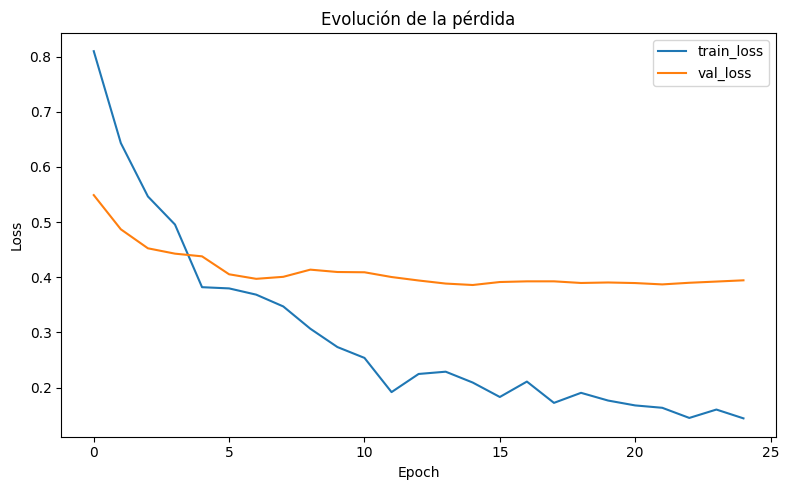

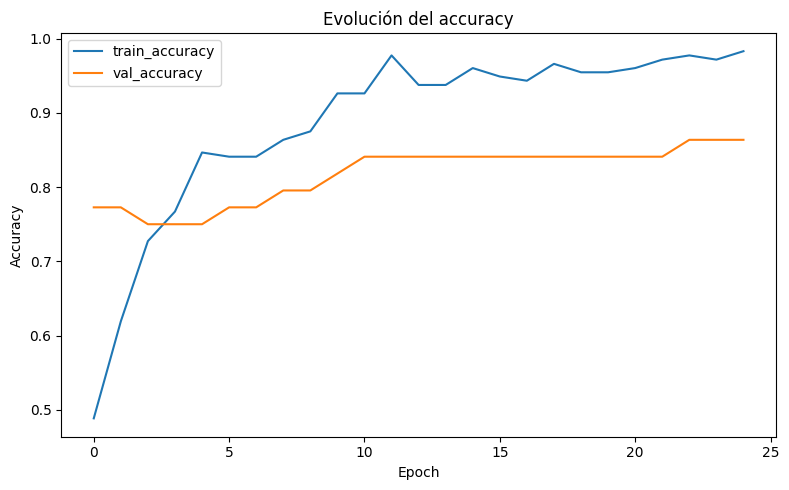

In [15]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

history_df.to_csv(REPORTS_PATH / '04B_custom_mlp_training_history.csv', index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df['loss'], label='train_loss')
plt.plot(history_df['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolución de la pérdida')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df['accuracy'], label='train_accuracy')
plt.plot(history_df['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Evolución del accuracy')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretación del resultado

En las últimas épocas, el accuracy de entrenamiento llega aproximadamente a 0.983 y el AUC a 0.999, mientras que validation accuracy queda alrededor de 0.864 y val_auc alrededor de 0.907.

Esto indica que la red aprende muy bien el conjunto de entrenamiento, pero no mejora al mismo nivel en validación. La diferencia entre entrenamiento y validación sugiere sobreajuste moderado, algo esperable por la cantidad de parámetros frente al tamaño del dataset.


## 15. Evaluación con threshold 0.50

La red produce probabilidades. Para convertirlas en clases se aplica un umbral: si prob_reuse es mayor o igual a 0.50, se predice reuso; si no, no reuso.

Este threshold de 0.50 es el punto de partida estándar, pero no siempre es el mejor. Por eso se evalúa primero y después se exploran otros umbrales.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
===== Custom MLP threshold 0.50 =====
Accuracy : 0.8409
Precision: 0.8261
Recall   : 0.8636
F1-score : 0.8444

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        22
           1       0.83      0.86      0.84        22

    accuracy                           0.84        44
   macro avg       0.84      0.84      0.84        44
weighted avg       0.84      0.84      0.84        44

Matriz de confusión:
[[18  4]
 [ 3 19]]


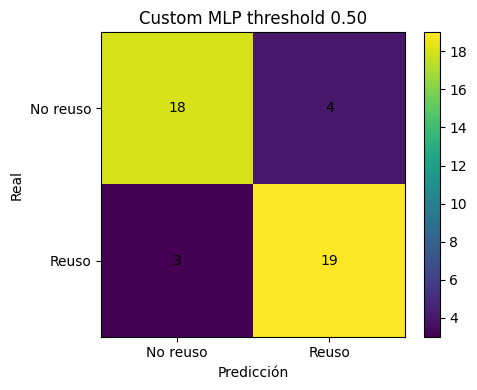

In [16]:
def evaluate_predictions(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    result = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'tn': cm[0, 0] if cm.shape == (2, 2) else np.nan,
        'fp': cm[0, 1] if cm.shape == (2, 2) else np.nan,
        'fn': cm[1, 0] if cm.shape == (2, 2) else np.nan,
        'tp': cm[1, 1] if cm.shape == (2, 2) else np.nan
    }

    print(f'===== {model_name} =====')
    print(f"Accuracy : {result['accuracy']:.4f}")
    print(f"Precision: {result['precision']:.4f}")
    print(f"Recall   : {result['recall']:.4f}")
    print(f"F1-score : {result['f1']:.4f}")
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, zero_division=0))
    print('Matriz de confusión:')
    print(cm)
    return result

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No reuso', 'Reuso'])
    ax.set_yticklabels(['No reuso', 'Reuso'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()

y_prob = custom_nn.predict(X_val_scaled).ravel()
y_pred = (y_prob >= NN_CONFIG['threshold']).astype(int)

base_result = evaluate_predictions('Custom MLP threshold 0.50', y_val, y_pred)
plot_confusion_matrix(y_val, y_pred, 'Custom MLP threshold 0.50')


### Interpretación del resultado

Con threshold 0.50, la MLP obtiene accuracy 0.8409 y F1 0.8444. La matriz de confusión muestra 18 verdaderos negativos, 4 falsos positivos, 3 falsos negativos y 19 verdaderos positivos.

Este resultado es útil como referencia inicial, pero deja margen de mejora porque el umbral estándar no necesariamente maximiza F1.


## 16. Búsqueda del mejor threshold

Se prueban umbrales desde 0.10 hasta 0.90 y se calcula el desempeño de cada uno. Luego se ordenan por F1-score.

Este paso es importante porque el umbral controla el balance entre falsos positivos y falsos negativos. Un threshold bajo aumenta recall, pero puede generar más falsos positivos. Un threshold alto suele hacer lo contrario.


===== Custom MLP threshold 0.10 =====
Accuracy : 0.6818
Precision: 0.6176
Recall   : 0.9545
F1-score : 0.7500

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.41      0.56        22
           1       0.62      0.95      0.75        22

    accuracy                           0.68        44
   macro avg       0.76      0.68      0.66        44
weighted avg       0.76      0.68      0.66        44

Matriz de confusión:
[[ 9 13]
 [ 1 21]]
===== Custom MLP threshold 0.15 =====
Accuracy : 0.7045
Precision: 0.6364
Recall   : 0.9545
F1-score : 0.7636

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.45      0.61        22
           1       0.64      0.95      0.76        22

    accuracy                           0.70        44
   macro avg       0.77      0.70      0.68        44
weighted avg       0.77      0.70      0.68        44

Matriz de confusión:
[[10 12]
 [ 1 21]

,model,accuracy,precision,recall,f1,tn,fp,fn,tp,threshold
0,Custom MLP threshold 0.40,0.863636,0.833333,0.909091,0.869565,18,4,2,20,0.40
1,Custom MLP threshold 0.35,0.863636,0.833333,0.909091,0.869565,18,4,2,20,0.35
2,Custom MLP threshold 0.45,0.863636,0.833333,0.909091,0.869565,18,4,2,20,0.45
3,Custom MLP threshold 0.30,0.840909,0.777778,0.954545,0.857143,16,6,1,21,0.30
4,Custom MLP threshold 0.50,0.840909,0.826087,0.863636,0.844444,18,4,3,19,0.50
5,Custom MLP threshold 0.25,0.795455,0.724138,0.954545,0.823529,14,8,1,21,0.25
6,Custom MLP threshold 0.55,0.818182,0.818182,0.818182,0.818182,18,4,4,18,0.55
7,Custom MLP threshold 0.20,0.772727,0.700000,0.954545,0.807692,13,9,1,21,0.20
8,Custom MLP threshold 0.15,0.704545,0.636364,0.954545,0.763636,10,12,1,21,0.15
9,Custom MLP threshold 0.60,0.772727,0.800000,0.727273,0.761905,18,4,6,16,0.60


Mejor threshold por F1: 0.40000000000000013


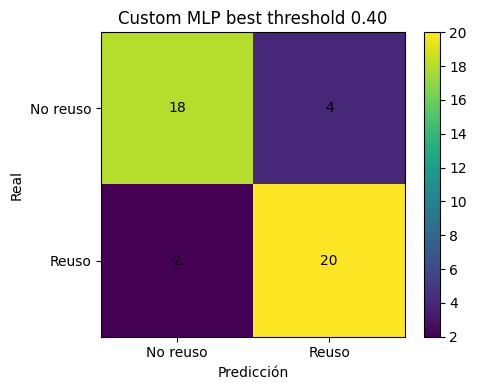

In [17]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    pred_t = (y_prob >= threshold).astype(int)
    result = evaluate_predictions(f'Custom MLP threshold {threshold:.2f}', y_val, pred_t)
    result['threshold'] = threshold
    threshold_results.append(result)

threshold_df = pd.DataFrame(threshold_results).sort_values('f1', ascending=False).reset_index(drop=True)
display(threshold_df.head(10))

threshold_df.to_csv(REPORTS_PATH / '04B_custom_mlp_threshold_results.csv', index=False)

best_threshold = float(threshold_df.loc[0, 'threshold'])
best_pred = (y_prob >= best_threshold).astype(int)

print('Mejor threshold por F1:', best_threshold)
plot_confusion_matrix(y_val, best_pred, f'Custom MLP best threshold {best_threshold:.2f}')


### Interpretación del resultado

El mejor threshold por F1 es 0.40, empatado con 0.35 y 0.45. Con threshold 0.40, el modelo obtiene accuracy 0.8636, precision 0.8333, recall 0.9091 y F1 0.8696.

La matriz correspondiente tiene 18 verdaderos negativos, 4 falsos positivos, 2 falsos negativos y 20 verdaderos positivos. Frente al threshold 0.50, se recupera un caso adicional de reuso, aunque se mantienen 4 falsos positivos.


## 17. Guardado del modelo, metadata y predicciones

Se guarda el modelo Keras final, un archivo de metadata con configuración completa y las predicciones de validación.

La metadata es tan importante como el modelo porque contiene scaler, configuración de features, threshold elegido y resultados. Sin esa información sería difícil reproducir exactamente el proceso de inferencia.


In [18]:
final_model_path = MODELS_PATH / '05_custom_mlp_final.keras'
custom_nn.save(final_model_path)

metadata_bundle = {
    'model_type': 'pretrained_code_embeddings_plus_custom_mlp',
    'pretrained_model_name': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'embedding_batch_size': BATCH_SIZE_EMBEDDINGS,
    'nn_config': NN_CONFIG,
    'best_threshold': best_threshold,
    'use_scaler': USE_SCALER,
    'scaler': scaler,
    'feature_config': {
        'USE_EMB_1': USE_EMB_1,
        'USE_EMB_2': USE_EMB_2,
        'USE_ABS_DIFF': USE_ABS_DIFF,
        'USE_PRODUCT': USE_PRODUCT,
        'USE_COSINE': USE_COSINE,
        'USE_L2_DISTANCE': USE_L2_DISTANCE
    },
    'input_dim': input_dim,
    'base_threshold_result': base_result,
    'threshold_results': threshold_df.to_dict(orient='records')
}

joblib.dump(metadata_bundle, MODELS_PATH / '05_custom_mlp_metadata.joblib')

predictions_df = val_df[['pair_id', 'language', 'file_1', 'file_2']].copy()
predictions_df['prob_reuse'] = y_prob
predictions_df['prediction_threshold_050'] = y_pred
predictions_df['prediction_best_threshold'] = best_pred
predictions_df['true_label'] = y_val
predictions_df['best_threshold'] = best_threshold

predictions_df.to_csv(REPORTS_PATH / '05_custom_mlp_val_predictions.csv', index=False)

print('Modelo final guardado en:', final_model_path)
print('Metadata guardada en:', MODELS_PATH / '05_custom_mlp_metadata.joblib')
print('Predicciones guardadas en:', REPORTS_PATH / '05_custom_mlp_val_predictions.csv')


Modelo final guardado en: data\models\05_custom_mlp_final.keras
Metadata guardada en: data\models\05_custom_mlp_metadata.joblib
Predicciones guardadas en: data\reports\05_custom_mlp_val_predictions.csv


### Interpretación del resultado

El modelo final, la metadata y las predicciones se guardaron correctamente. Esto convierte el experimento en artefactos reutilizables: el modelo puede cargarse después, la metadata explica cómo preparar las features y el CSV permite analizar predicciones caso por caso.


## 18. Comparación con etapas anteriores

Se reúnen los mejores resultados de notebooks previos y se comparan contra la MLP personalizada.

Esta comparación responde la pregunta central del experimento: si la red neuronal personalizada sobre embeddings mejora o no los enfoques anteriores. Comparar por F1 permite evaluar el equilibrio entre detectar reuso y evitar falsas alarmas.


In [20]:
comparison_tables = []

paths_to_compare = [
    ('03_baseline', REPORTS_PATH / '03_baseline_model_results.csv'),
    ('04_transformer_classic', REPORTS_PATH / '04_transformer_embedding_model_results.csv'),
    ('05_final', REPORTS_PATH / '05_final_model_comparison.csv')
]

for stage, path in paths_to_compare:
    if path.exists():
        temp = pd.read_csv(path)
        if 'f1' in temp.columns:
            best = temp.sort_values('f1', ascending=False).head(1).copy()
            best['stage'] = stage
            comparison_tables.append(best)

custom_best = threshold_df.head(1).copy()
custom_best['stage'] = '04B_custom_mlp'
comparison_tables.append(custom_best)

comparison = pd.concat(comparison_tables, ignore_index=True)

cols = ['stage', 'model', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp']
extra = [c for c in ['threshold'] if c in comparison.columns]
comparison = comparison[cols + extra]

display(comparison.sort_values('f1', ascending=False))
comparison.to_csv(REPORTS_PATH / '04B_custom_mlp_comparison.csv', index=False)


,stage,model,accuracy,precision,recall,f1,tn,fp,fn,tp,threshold
0,03_baseline,Linear SVM,0.931818,0.880000,1.000000,0.936170,19,3,0,22,NaN
1,04_transformer_classic,Embedding Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20,NaN
2,04B_custom_mlp,Custom MLP threshold 0.40,0.863636,0.833333,0.909091,0.869565,18,4,2,20,0.4


### Interpretación del resultado

La comparación final muestra que el mejor resultado sigue siendo el baseline TF-IDF del notebook 03 con F1 0.9362. El Random Forest sobre embeddings del notebook 04 obtiene F1 0.9091, y la MLP personalizada queda en F1 0.8696.

Esto es muy relevante: aunque la MLP es más compleja, no supera a los modelos anteriores. La conclusión práctica es que, para este dataset pequeño, una representación TF-IDF bien construida y un SVM lineal generalizan mejor que una red neuronal grande sobre embeddings congelados.


## 19. Función de predicción para código nuevo

Se define una función que recibe dos fragmentos de código, genera embeddings, construye features, aplica el scaler, predice probabilidad de reuso y devuelve la etiqueta final.

Esta función demuestra cómo usar el modelo entrenado fuera del dataset de validación, en un caso manual. Es el puente entre el experimento y una posible herramienta práctica.


In [21]:
def predict_code_pair_custom_nn(code_1, code_2, threshold=None):
    if threshold is None:
        threshold = best_threshold

    emb1 = encode_texts([code_1], tokenizer, transformer_model, MAX_LENGTH, 1, device)
    emb2 = encode_texts([code_2], tokenizer, transformer_model, MAX_LENGTH, 1, device)

    X = build_pair_features(emb1, emb2)

    if scaler is not None:
        X = scaler.transform(X)

    prob = float(custom_nn.predict(X).ravel()[0])
    pred = int(prob >= threshold)

    return {
        'prob_reuse': prob,
        'threshold': threshold,
        'prediction': pred,
        'prediction_label': 'Reuso' if pred == 1 else 'No reuso',
        'cosine_similarity': float(rowwise_cosine(emb1, emb2)[0]),
        'l2_distance': float(rowwise_l2(emb1, emb2)[0])
    }

example_code_1 = '''
public class Main {
    public static void main(String[] args) {
        int a = 5;
        int b = 10;
        System.out.println(a + b);
    }
}
'''

example_code_2 = '''
public class Solution {
    public static void main(String[] args) {
        int x = 5;
        int y = 10;
        System.out.println(x + y);
    }
}
'''

predict_code_pair_custom_nn(example_code_1, example_code_2)


Batch 1/1
Batch 1/1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


{'prob_reuse': 0.96736741065979,
 'threshold': 0.40000000000000013,
 'prediction': 1,
 'prediction_label': 'Reuso',
 'cosine_similarity': 0.9996638298034668,
 'l2_distance': 0.5687496662139893}

### Interpretación del resultado

La prueba manual predice Reuso para dos programas Java casi idénticos, con prob_reuse aproximada de 0.9674, threshold 0.40, similitud coseno 0.9997 y distancia L2 0.5687.

El resultado es coherente porque ambos códigos comparten la misma estructura y solo cambian nombres. Esta prueba confirma que la función de inferencia completa funciona de extremo a extremo.
